# 🚦 Traffic Volume Prediction using Machine Learning

## 📌 Objective
Predict traffic volume using temporal features and regression models.

## 🧠 Models Used
- Linear Regression
- Decision Tree
- Random Forest

## 📊 Features
- Hour
- Day
- Month
- Weekday
- Rush Hour Indicator

## TASK 2 — Import Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## TASK 3 — Load Dataset

In [46]:
df = pd.read_csv("datafile.csv")
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [47]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48204 non-null  int64  
 1   holiday              61 non-null     str    
 2   temp                 48204 non-null  float64
 3   rain_1h              48204 non-null  float64
 4   snow_1h              48204 non-null  float64
 5   clouds_all           48204 non-null  int64  
 6   weather_main         48204 non-null  str    
 7   weather_description  48204 non-null  str    
 8   date_time            48204 non-null  str    
dtypes: float64(3), int64(2), str(4)
memory usage: 4.8 MB


,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,3259.818355,281.205870,0.334264,0.000222,49.362231
std,1986.860670,13.338232,44.789133,0.008168,39.015750
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1193.000000,272.160000,0.000000,0.000000,1.000000
50%,3380.000000,282.450000,0.000000,0.000000,64.000000
75%,4933.000000,291.806000,0.000000,0.000000,90.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000


In [48]:
df.drop_duplicates(inplace=True)
df.shape

(48187, 9)

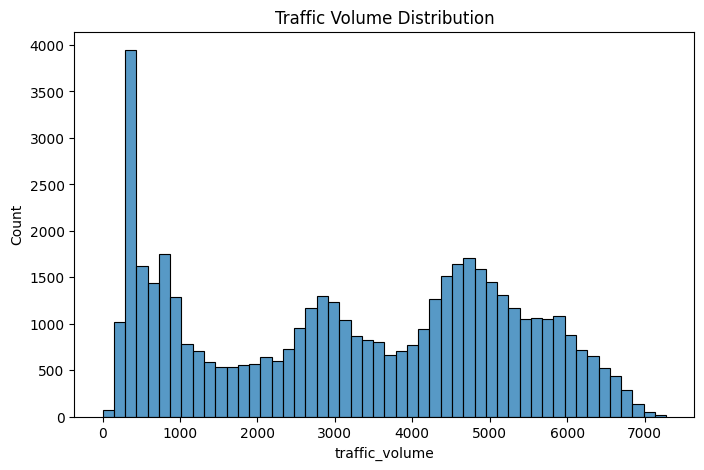

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(df['traffic_volume'], bins=50)
plt.title("Traffic Volume Distribution")
plt.show()

In [50]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True)

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday

# Rush hour feature
df['is_rush'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)

df.drop('date_time', axis=1, inplace=True)

df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,hour,day,month,weekday,is_rush
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,9,2,10,1,1
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,10,2,10,1,0
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,11,2,10,1,0
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,12,2,10,1,0
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,13,2,10,1,0


In [51]:
X = df[['hour', 'day', 'month', 'weekday', 'is_rush']]
y = df['traffic_volume']

In [52]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr_model = LinearRegression()
dt_model = DecisionTreeRegressor()
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

lr_model.fit(x_train, y_train)
dt_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [54]:
from sklearn.metrics import mean_squared_error, r2_score

lr_pred = lr_model.predict(x_test)
dt_pred = dt_model.predict(x_test)
rf_pred = rf_model.predict(x_test)

lr_mse = mean_squared_error(y_test, lr_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

lr_r2 = r2_score(y_test, lr_pred)
dt_r2 = r2_score(y_test, dt_pred)
rf_r2 = r2_score(y_test, rf_pred)

In [55]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MSE": [lr_mse, dt_mse, rf_mse],
    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

results.style.background_gradient(cmap="Blues")

,Model,MSE,R2 Score
0,Linear Regression,3030710.973782,0.240217
1,Decision Tree,202034.364781,0.949351
2,Random Forest,188481.314802,0.952749


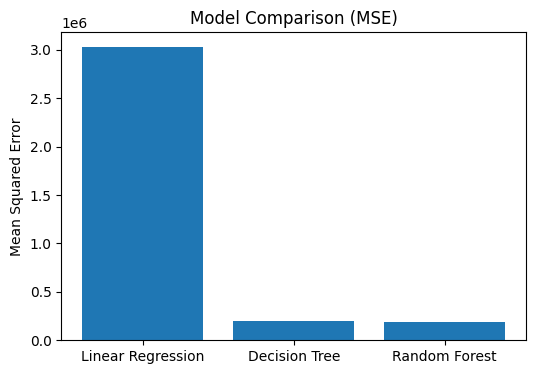

In [56]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MSE"])
plt.title("Model Comparison (MSE)")
plt.ylabel("Mean Squared Error")
plt.show()

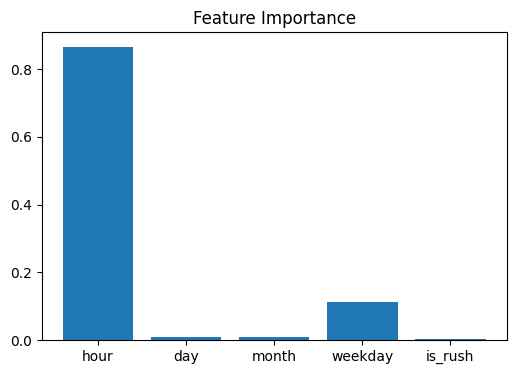

In [57]:
features = X.columns
importance = rf_model.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

In [58]:
sample = np.array([[8, 15, 6, 2, 1]])
rf_model.predict(sample)

/Users/sarathpatti/Desktop/Traffice-Volume/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([5739.78241507])

In [59]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

joblib.dump(rf_model, "saved_models/Random_Forest.pkl")

['saved_models/Random_Forest.pkl']

## ✅ Conclusion

- Random Forest performed best with lowest MSE
- Feature engineering (weekday + rush hour) improved predictions
- Linear models failed due to non-linearity
- Final model deployed using Streamlit

## 🚀 Future Work
- Add weather data
- Use XGBoost
- Deploy real-time system

In [60]:
import sqlite3

conn = sqlite3.connect("users.db")
c = conn.cursor()

c.execute("""
CREATE TABLE IF NOT EXISTS users (
    username TEXT PRIMARY KEY,
    password TEXT
)
""")

conn.commit()
conn.close()

print("Database ready!")

Database ready!
